In [34]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sqlite3
import seaborn as sns

In [35]:
import sqlite3
import pandas as pd
from pathlib import Path

def load_db(db_path):
    """Load runs and results tables from SQLite database."""
    db_path = Path(db_path)
    if not db_path.exists():
        raise FileNotFoundError(f"Database not found: {db_path}")
    
    with sqlite3.connect(db_path) as conn:
        runs = pd.read_sql_query("SELECT * FROM runs", conn)
        results = pd.read_sql_query("SELECT * FROM results", conn)
    
    return runs, results

def merge_runs_results(runs, results):
    """Join runs and results tables on run_id."""
    merged = results.merge(runs, on="run_id", how="left")
    return merged

# Load folio-results.db
folio_runs, folio_results = load_db("folio-results.db")
folio_merged = merge_runs_results(folio_runs, folio_results)

print(f"folio-results.db loaded:")
print(f"  Runs: {len(folio_runs)} rows")
print(f"  Results: {len(folio_results)} rows")
print(f"  Merged: {len(folio_merged)} rows")
print(f"\nColumns in merged data:\n{folio_merged.columns.tolist()}")

folio-results.db loaded:
  Runs: 3 rows
  Results: 840 rows
  Merged: 840 rows

Columns in merged data:
['result_id', 'run_id', 'problem_id', 'path', 'status', 'elapsed_ms', 'formulae', 'atoms', 'unknown_reason', 'label', 'timestamp', 'engine', 'timeout_ms', 'max_depth', 'max_steps', 'max_fresh_terms_per_quantifier', 'problem_class']


In [36]:
folio_merged.head()

,result_id,run_id,problem_id,path,status,elapsed_ms,formulae,atoms,unknown_reason,label,timestamp,engine,timeout_ms,max_depth,max_steps,max_fresh_terms_per_quantifier,problem_class
0,1,1,validation__325__entails,..\FOLIO\generated\validation__325__entails.p,not_provable,28,None,None,None,naive_20260511_123853,2026-05-11T12:38:53+10:00,naive,1000,128,10000,1,mixed
1,2,1,validation__325__refutes,..\FOLIO\generated\validation__325__refutes.p,provable,74,None,None,None,naive_20260511_123853,2026-05-11T12:38:53+10:00,naive,1000,128,10000,1,mixed
2,3,1,validation__1271__refutes,..\FOLIO\generated\validation__1271__refutes.p,unknown,864,None,None,quantifier_budget,naive_20260511_123853,2026-05-11T12:38:53+10:00,naive,1000,128,10000,1,mixed
3,4,1,validation__360__entails,..\FOLIO\generated\validation__360__entails.p,provable,11,None,None,None,naive_20260511_123853,2026-05-11T12:38:53+10:00,naive,1000,128,10000,1,mixed
4,5,1,validation__1365__entails,..\FOLIO\generated\validation__1365__entails.p,unknown,935,None,None,max_steps,naive_20260511_123853,2026-05-11T12:38:53+10:00,naive,1000,128,10000,1,mixed


In [37]:
# Filter folio_merged by engine: separate runs for naive, id, and priority-id
naive_runs = folio_merged[folio_merged['engine'] == 'naive']
id_runs = folio_merged[folio_merged['engine'] == 'id']
priority_id_runs = folio_merged[folio_merged['engine'] == 'priority-id']

print(f"Engine breakdown:")
print(f"  naive: {len(naive_runs)} rows")
print(f"  id: {len(id_runs)} rows")
print(f"  priority-id: {len(priority_id_runs)} rows")
print(f"  Total: {len(naive_runs) + len(id_runs) + len(priority_id_runs)} rows")

# Show sample from each
print(f"\nSample from naive_runs:")
print(naive_runs[['engine', 'problem_id', 'status', 'elapsed_ms']].head())
print(f"\nSample from id_runs:")
print(id_runs[['engine', 'problem_id', 'status', 'elapsed_ms']].head())
print(f"\nSample from priority_id_runs:")
print(priority_id_runs[['engine', 'problem_id', 'status', 'elapsed_ms']].head())

Engine breakdown:
  naive: 280 rows
  id: 280 rows
  priority-id: 280 rows
  Total: 840 rows

Sample from naive_runs:
  engine                 problem_id        status  elapsed_ms
0  naive   validation__325__entails  not_provable          28
1  naive   validation__325__refutes      provable          74
2  naive  validation__1271__refutes       unknown         864
3  naive   validation__360__entails      provable          11
4  naive  validation__1365__entails       unknown         935

Sample from id_runs:
    engine                 problem_id        status  elapsed_ms
280     id   validation__325__entails  not_provable           4
281     id   validation__241__refutes      provable          18
282     id   validation__325__refutes      provable          10
283     id   validation__622__entails      provable         610
284     id  validation__1271__refutes       unknown         723

Sample from priority_id_runs:
          engine                problem_id        status  elapsed_ms
560 

In [38]:
# Create summary table: engine + status -> count
summary = folio_merged.groupby(['engine', 'status']).size().reset_index(name='count')
summary_pivot = summary.pivot(index='engine', columns='status', values='count').fillna(0).astype(int)

print("Summary: Count of results by engine and status")
print("=" * 60)
print(summary_pivot)
print("\nTotal rows per engine:")
print(summary_pivot.sum(axis=1))
print(f"\nGrand total: {summary_pivot.sum().sum()} rows")

Summary: Count of results by engine and status
status       not_provable  provable  timeout  unknown
engine                                               
id                     17        40      198       25
naive                  23        34      204       19
priority-id            28        38      204       10

Total rows per engine:
engine
id             280
naive          280
priority-id    280
dtype: int64

Grand total: 840 rows



FOLIO Results Summary
     Engine  Gathered  Timeout  Unknown  Total
      naive        57      204       19    280
         id        57      198       25    280
priority-id        66      204       10    280


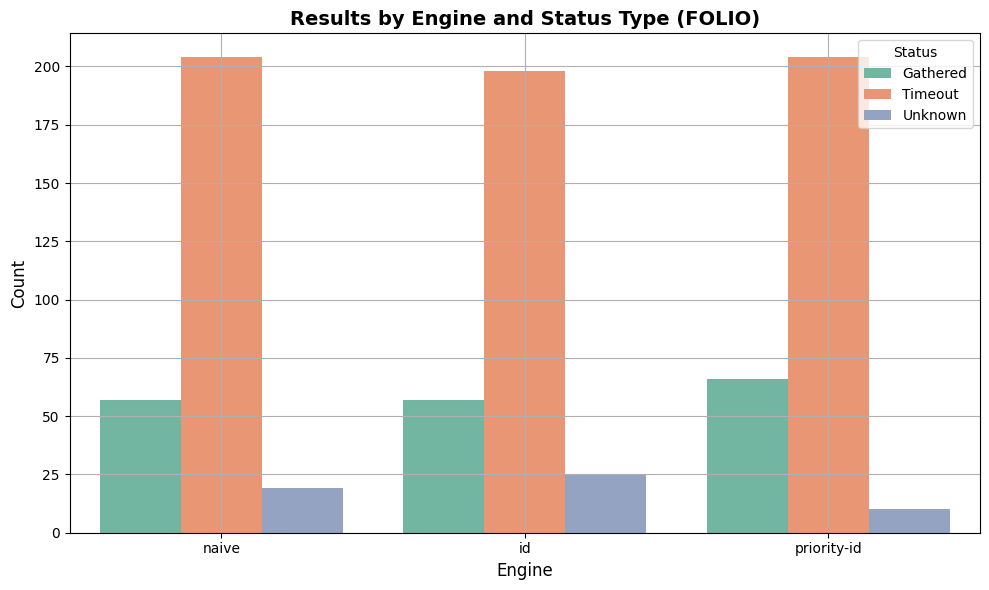

In [39]:
# Create a cleaner summary: gathered (provable + not_provable), timeout, unknown
status_summary = []
for engine in folio_merged['engine'].unique():
    engine_data = folio_merged[folio_merged['engine'] == engine]
    gathered = len(engine_data[engine_data['status'].isin(['provable', 'not_provable'])])
    timeout = len(engine_data[engine_data['status'] == 'timeout'])
    unknown = len(engine_data[engine_data['status'] == 'unknown'])
    total = len(engine_data)
    
    status_summary.append({'Engine': engine, 'Gathered': gathered, 'Timeout': timeout, 'Unknown': unknown, 'Total': total})

summary_df = pd.DataFrame(status_summary)
print("\nFOLIO Results Summary")
print("=" * 70)
print(summary_df.to_string(index=False))
print("=" * 70)

# Create barplot
fig, ax = plt.subplots(figsize=(10, 6))
summary_df_melted = summary_df.melt(id_vars='Engine', value_vars=['Gathered', 'Timeout', 'Unknown'], var_name='Status', value_name='Count')

sns.barplot(data=summary_df_melted, x='Engine', y='Count', hue='Status', ax=ax, palette='Set2')
plt.grid()
ax.set_title('Results by Engine and Status Type (FOLIO)', fontsize=14, fontweight='bold')
ax.set_ylabel('Count', fontsize=12)
ax.set_xlabel('Engine', fontsize=12)
ax.legend(title='Status', fontsize=10)
plt.tight_layout()
plt.savefig("results/folio_engine_status_summary.png")
plt.show()

C:\Users\madel\AppData\Local\Temp\ipykernel_3544\2744980294.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="engine", y="elapsed_ms", palette="Set2")


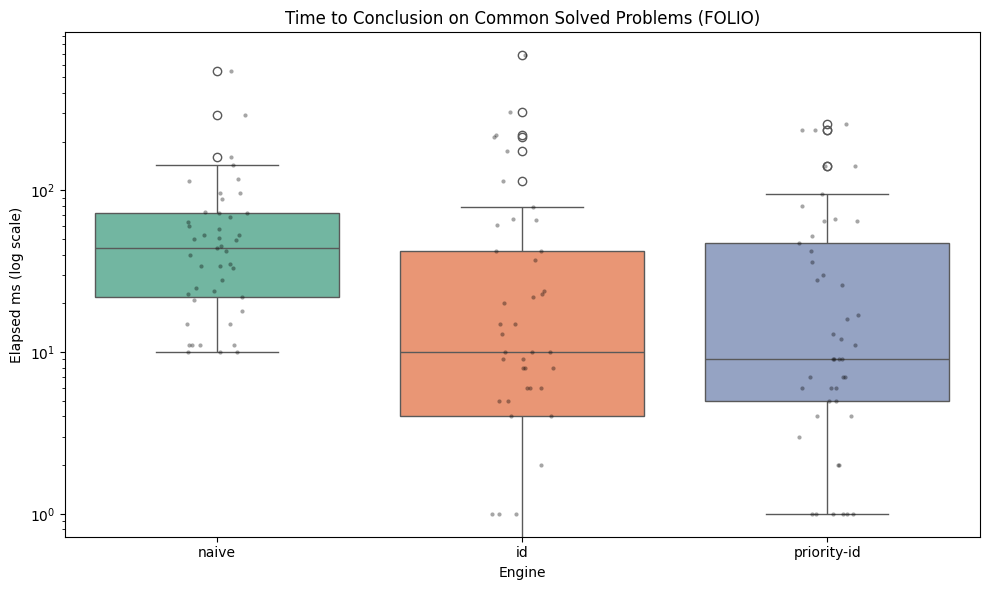

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Keep only determined results
solved = folio_merged[folio_merged["status"].isin(["provable", "not_provable"])].copy()

# 2. Keep only problems solved by every engine
engines = solved["engine"].unique()
problem_counts = solved.groupby("problem_id")["engine"].nunique()
common_problems = problem_counts[problem_counts == len(engines)].index

common_solved = solved[solved["problem_id"].isin(common_problems)].copy()

# 3. One row per problem per engine
plot_df = common_solved[["problem_id", "engine", "elapsed_ms"]].copy()

plt.figure(figsize=(10, 6))
sns.boxplot(data=plot_df, x="engine", y="elapsed_ms", palette="Set2")
sns.stripplot(data=plot_df, x="engine", y="elapsed_ms", color="black", alpha=0.35, size=3)
plt.yscale("log")  # helps if times are very skewed
plt.title("Time to Conclusion on Common Solved Problems (FOLIO)")
plt.xlabel("Engine")
plt.ylabel("Elapsed ms (log scale)")
plt.tight_layout()
plt.savefig("results/folio_engine_conclusion_time.png")
plt.show()

tptp-provable-results.db loaded:
  Runs: 3 rows
  Results: 2211 rows
  Merged: 2211 rows


TPTP Provable Results Summary
     Engine  Gathered  Timeout  Unknown  Total
      naive       152      573       12    737
         id       199      526       12    737
priority-id       209      516       12    737


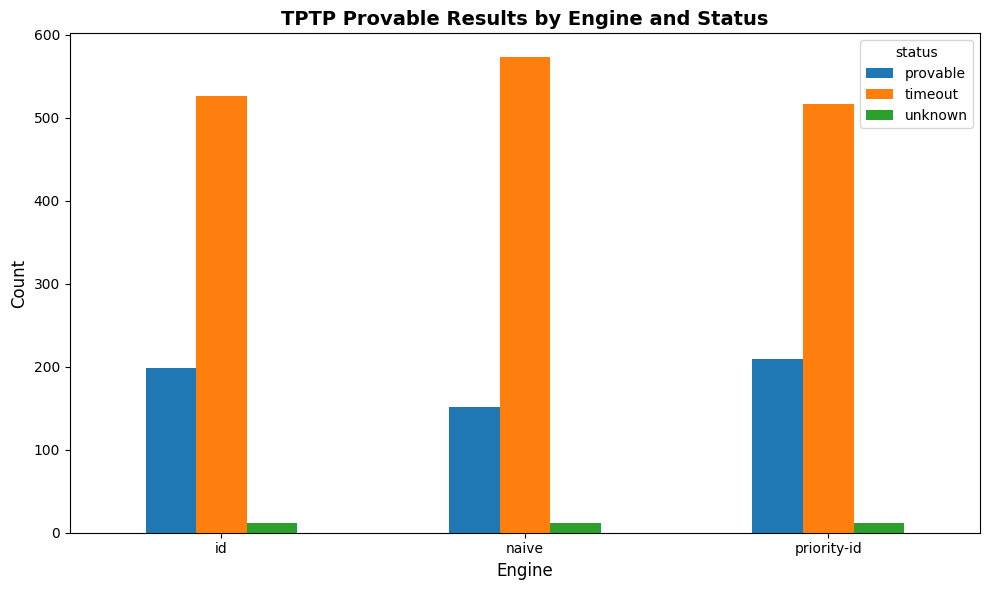

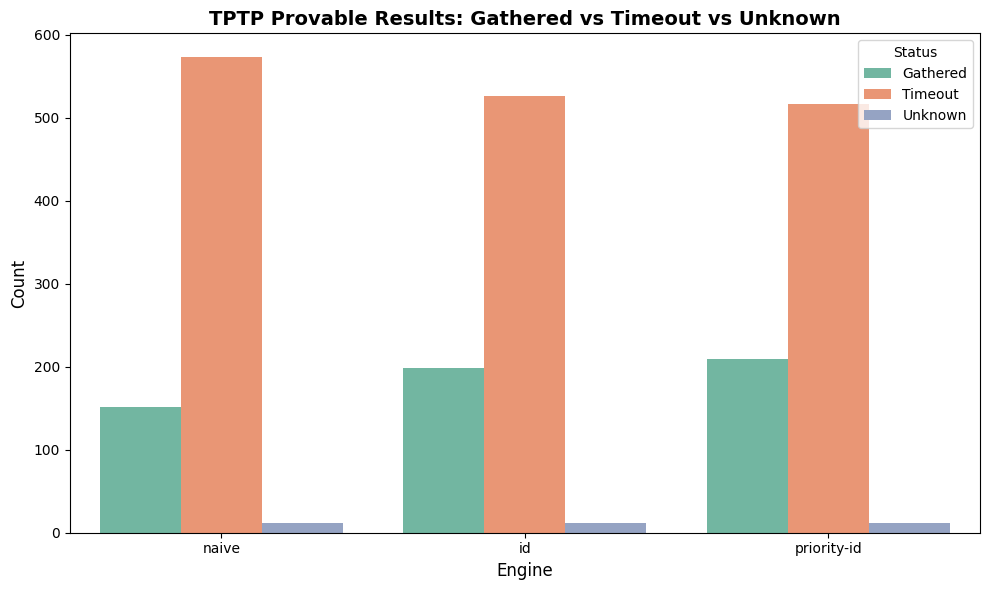

C:\Users\madel\AppData\Local\Temp\ipykernel_3544\2131447735.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='engine', y='elapsed_ms', palette='Set3', ax=ax)


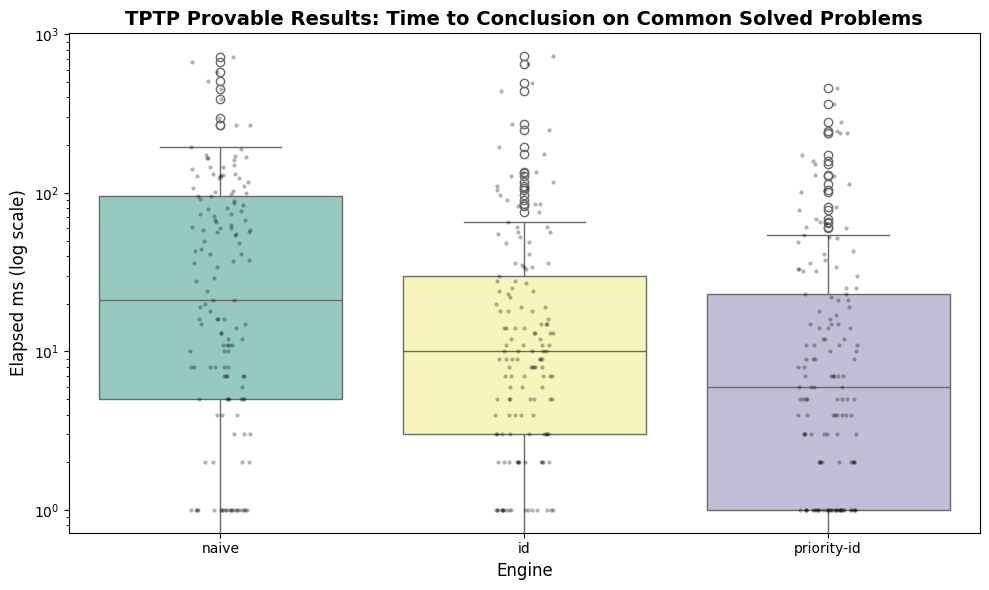

,problem_id,engine,elapsed_ms
0,SYN392+1,naive,1
1,SYN915+1,naive,0
2,SYN398+1,naive,1
3,SYN393+1.003,naive,10
4,LCL662+1.001,naive,10
...,...,...,...
2034,LCL644+1.001,priority-id,174
2044,GEO220+1,priority-id,30
2062,CSR069+1,priority-id,32
2064,CSR053+1,priority-id,49


In [41]:
# Repeat the same three plots for tptp-provable-results.db
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


def load_and_merge_db(db_path):
    runs, results = load_db(db_path)
    merged = merge_runs_results(runs, results)
    return runs, results, merged


def print_summary_table(merged, title):
    """Print a summary table of engine counts by status."""
    status_summary = []
    for engine_name in merged['engine'].dropna().unique():
        engine_data = merged[merged['engine'] == engine_name]
        gathered = len(engine_data[engine_data['status'].isin(['provable', 'not_provable'])])
        timeout = len(engine_data[engine_data['status'] == 'timeout'])
        unknown = len(engine_data[engine_data['status'] == 'unknown'])
        total = len(engine_data)
        status_summary.append({
            'Engine': engine_name,
            'Gathered': gathered,
            'Timeout': timeout,
            'Unknown': unknown,
            'Total': total
        })
    
    summary_df = pd.DataFrame(status_summary)
    print(f"\n{title}")
    print("=" * 70)
    print(summary_df.to_string(index=False))
    print("=" * 70)
    return summary_df


def load_engine_status_counts(merged, title):
    status_summary = (
        merged.groupby(['engine', 'status'])
        .size()
        .reset_index(name='count')
    )
    summary_pivot = (
        status_summary.pivot(index='engine', columns='status', values='count')
        .fillna(0)
        .astype(int)
    )

    ax = summary_pivot.plot(kind='bar', figsize=(10, 6))
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Engine', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return summary_pivot


def plot_engine_status_counts(merged, title):
    status_summary = (
        merged.groupby(['engine', 'status'])
        .size()
        .reset_index(name='count')
    )
    summary_pivot = (
        status_summary.pivot(index='engine', columns='status', values='count')
        .fillna(0)
        .astype(int)
    )

    ax = summary_pivot.plot(kind='bar', figsize=(10, 6))
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Engine', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return summary_pivot


def plot_result_type_counts(merged, title):
    status_summary = []
    for engine_name in merged['engine'].dropna().unique():
        engine_data = merged[merged['engine'] == engine_name]
        gathered = len(engine_data[engine_data['status'].isin(['provable', 'not_provable'])])
        timeout = len(engine_data[engine_data['status'] == 'timeout'])
        unknown = len(engine_data[engine_data['status'] == 'unknown'])
        status_summary.append(
            {'Engine': engine_name, 'Gathered': gathered, 'Timeout': timeout, 'Unknown': unknown}
        )

    summary_df = pd.DataFrame(status_summary)
    summary_df_melted = summary_df.melt(id_vars='Engine', var_name='Status', value_name='Count')

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(data=summary_df_melted, x='Engine', y='Count', hue='Status', ax=ax, palette='Set2')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel('Count', fontsize=12)
    ax.set_xlabel('Engine', fontsize=12)
    plt.tight_layout()
    plt.show()

    return summary_df


def plot_common_solved_timing(merged, title):
    solved = merged[merged['status'].isin(['provable', 'not_provable'])].copy()
    engines = solved['engine'].dropna().unique()
    if len(engines) == 0:
        print('No solved rows available for timing comparison.')
        return pd.DataFrame()

    common_problems = (
        solved.groupby('problem_id')['engine'].nunique()
        .pipe(lambda counts: counts[counts == len(engines)].index)
    )
    common_solved = solved[solved['problem_id'].isin(common_problems)].copy()
    plot_df = common_solved[['problem_id', 'engine', 'elapsed_ms']].copy()

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.boxplot(data=plot_df, x='engine', y='elapsed_ms', palette='Set3', ax=ax)
    sns.stripplot(data=plot_df, x='engine', y='elapsed_ms', color='black', alpha=0.3, size=3, ax=ax)
    ax.set_yscale('log')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Engine', fontsize=12)
    ax.set_ylabel('Elapsed ms (log scale)', fontsize=12)
    plt.tight_layout()
    plt.show()

    return plot_df


# Load and plot tptp-provable-results.db
candidate_paths = [Path('analysis/tptp-provable-results.db'), Path('tptp-provable-results.db')]
tptp_db_path = next((path for path in candidate_paths if path.exists()), candidate_paths[0])
tptp_runs, tptp_results, tptp_merged = load_and_merge_db(tptp_db_path)

print(f'{tptp_db_path} loaded:')
print(f'  Runs: {len(tptp_runs)} rows')
print(f'  Results: {len(tptp_results)} rows')
print(f'  Merged: {len(tptp_merged)} rows')
print()

print_summary_table(tptp_merged, 'TPTP Provable Results Summary')
plot_engine_status_counts(tptp_merged, 'TPTP Provable Results by Engine and Status')
plot_result_type_counts(tptp_merged, 'TPTP Provable Results: Gathered vs Timeout vs Unknown')
plot_common_solved_timing(tptp_merged, 'TPTP Provable Results: Time to Conclusion on Common Solved Problems')

tptp-unprovable-results.db loaded:
  Runs: 3 rows
  Results: 453 rows
  Merged: 453 rows


TPTP Unprovable Results Summary
     Engine  Gathered  Timeout  Unknown  Total
      naive         4      143        4    151
         id         4      143        4    151
priority-id         4      142        5    151


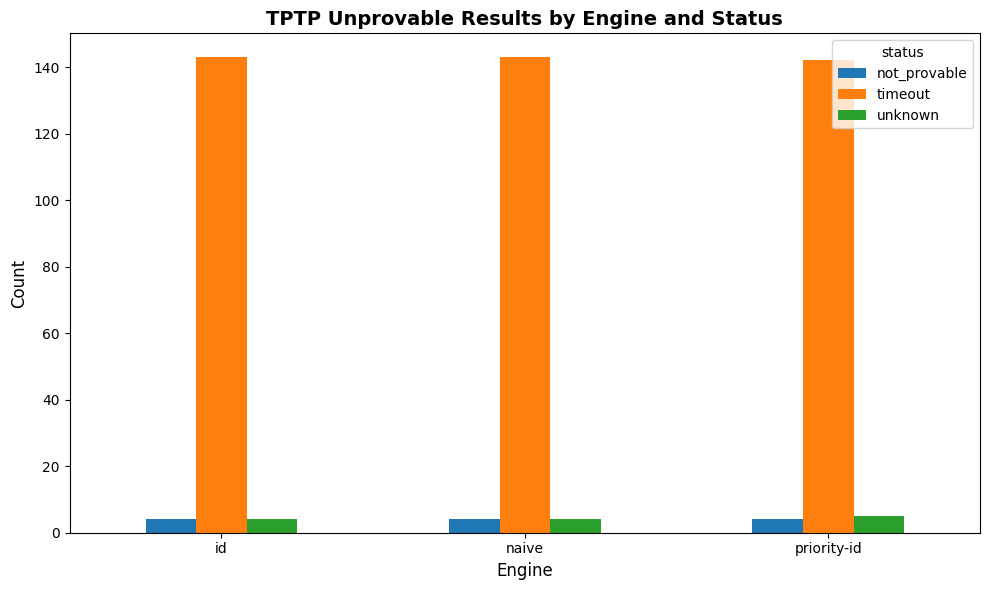

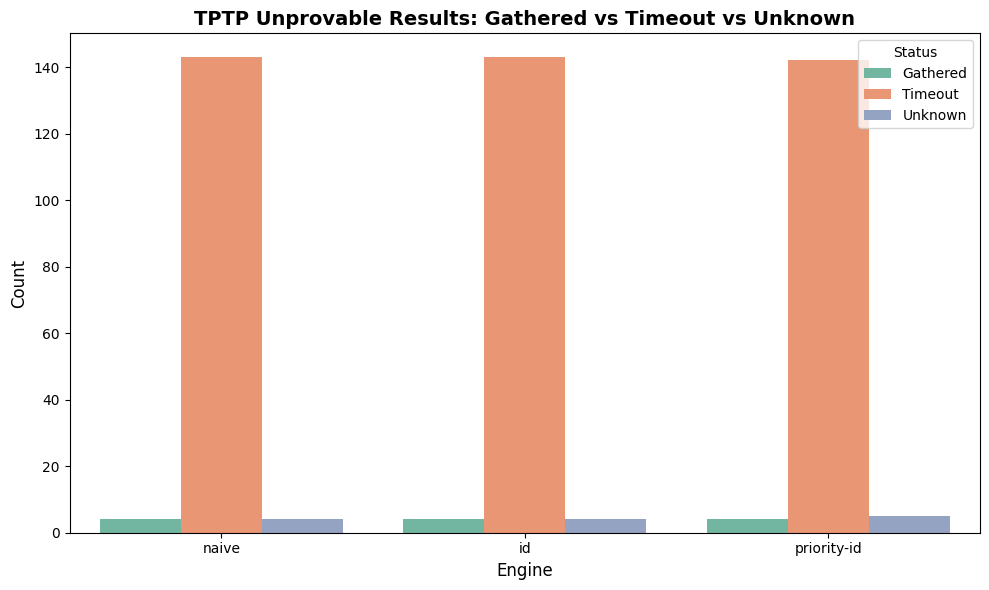

C:\Users\madel\AppData\Local\Temp\ipykernel_3544\2131447735.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='engine', y='elapsed_ms', palette='Set3', ax=ax)


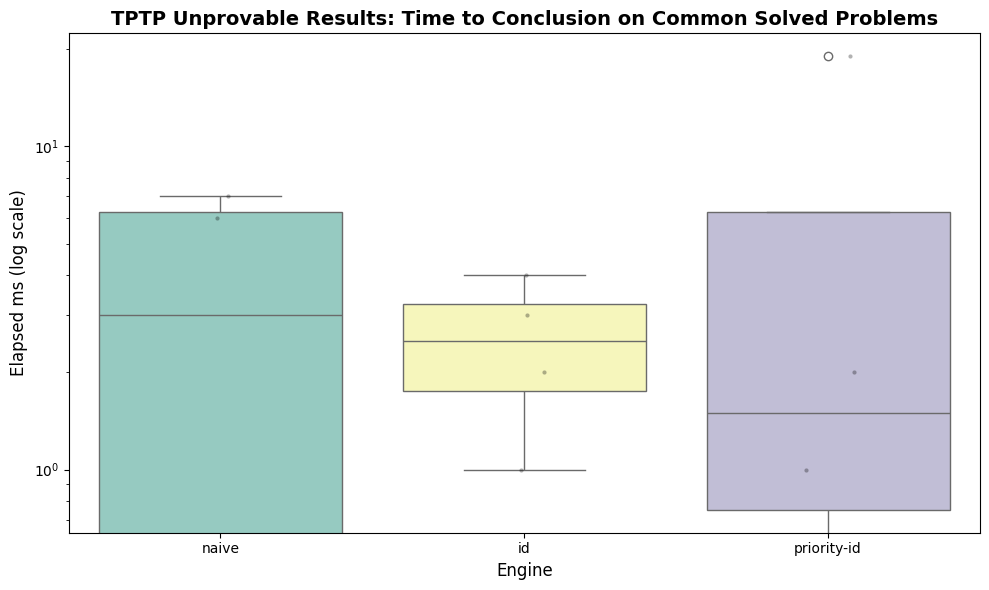

,problem_id,engine,elapsed_ms
0,LCL663+1.001,naive,7
1,LCL681+1.001,naive,0
2,SYN916+1,naive,6
3,LCL679+1.001,naive,0
151,LCL663+1.001,id,2
152,LCL681+1.001,id,4
153,SYN916+1,id,3
154,LCL679+1.001,id,1
302,LCL663+1.001,priority-id,19
303,LCL681+1.001,priority-id,2


In [42]:
# Load and plot tptp-unprovable-results.db
candidate_paths = [Path('analysis/tptp-unprovable-results.db'), Path('tptp-unprovable-results.db')]
tptp_unprv_db_path = next((path for path in candidate_paths if path.exists()), candidate_paths[0])
tptp_unprv_runs, tptp_unprv_results, tptp_unprv_merged = load_and_merge_db(tptp_unprv_db_path)

print(f'{tptp_unprv_db_path} loaded:')
print(f'  Runs: {len(tptp_unprv_runs)} rows')
print(f'  Results: {len(tptp_unprv_results)} rows')
print(f'  Merged: {len(tptp_unprv_merged)} rows')
print()

print_summary_table(tptp_unprv_merged, 'TPTP Unprovable Results Summary')
plot_engine_status_counts(tptp_unprv_merged, 'TPTP Unprovable Results by Engine and Status')
plot_result_type_counts(tptp_unprv_merged, 'TPTP Unprovable Results: Gathered vs Timeout vs Unknown')
plot_common_solved_timing(tptp_unprv_merged, 'TPTP Unprovable Results: Time to Conclusion on Common Solved Problems')